In [776]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [777]:
%run ~/Dropbox/Nonlinear/Experiments/CODE/LABCodes/ComputeDelays.py

In [778]:
def compdelay(t,sig1,sig2,sig3,winlen=10,probe_filter_cut=1.5e6):

    activechannelnames=[0]
    
    probedat=[timedata(ch) for ch in activechannelnames]
    PUMPdat=[timedata(ch) for ch in activechannelnames]
    bothdat=[timedata(ch) for ch in activechannelnames]
    
    probedat[0].time=t
    probedat[0].data=sig1
    
    PUMPdat[0].time=t
    PUMPdat[0].data=sig2
    
    bothdat[0].time=t
    bothdat[0].data=sig3
    
    tshift=Compute_single_delay(bothdat,probedat,PUMPdat,0,winlen,probe_filter_cut=probe_filter_cut)

    return tshift

In [851]:
#fnamestart='1B/35.7/'
#fnamestart='6B/34.6/'
#fnamestart='5B/65.5/'
#fnamestart='5A/104.5/'
#fnamestart='4A/68.4/'
#fnamestart='2A/32/'
fnamestart='2B/35.4/'

#datb=np.load(fnamestart+'BOTH(filter-morepulses).npy')
#dat2=np.load(fnamestart+'PUMP(filter-morepulses).npy')
#dat1=np.load(fnamestart+'PROBE(filter-morepulses).npy')

datb=np.load(fnamestart+'BOTH(filter).npy')
dat2=np.load(fnamestart+'PUMP(filter).npy')
dat1=np.load(fnamestart+'PROBE(filter).npy')

#datb=np.load(fnamestart+'BOTH(nofilter).npy')
#dat2=np.load(fnamestart+'PUMP(nofilter).npy')
#dat1=np.load(fnamestart+'PROBE(nofilter).npy')

In [852]:
n2hf=int(np.size(dat2)/2)
t2=dat2[:n2hf]*1e6
d2=dat2[n2hf:]

In [853]:
nbhf=int(np.size(datb)/2)
tb=datb[:nbhf]*1e6
db=datb[nbhf:]
ddiff=db-d2

In [854]:
n1hf=int(np.size(dat1)/2)
t1=dat1[:n1hf]*1e6
d1=dat1[n1hf:]

In [855]:
#check that all of the time vectors are the same
np.max(np.abs(tb-t1))
t=t1
dt=t[1]-t[0]
nt=np.size(t)

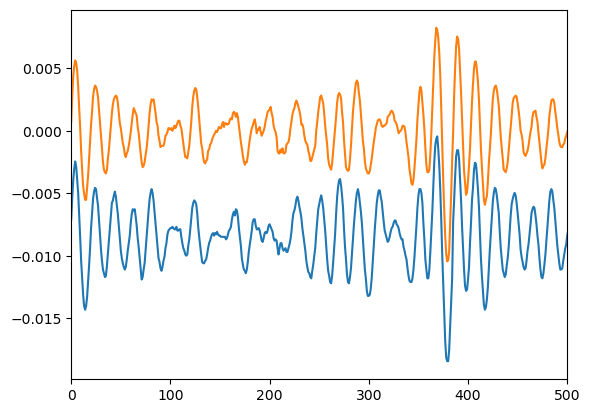

In [857]:
plt.plot(d1)
#plt.plot(t2,d2)
plt.plot(db-d2)
plt.xlim([0,500])
ntend=500 #set to 100 if pulse is in first 100 points, 500 if it's in the first 500

(-10.0, 40.0)

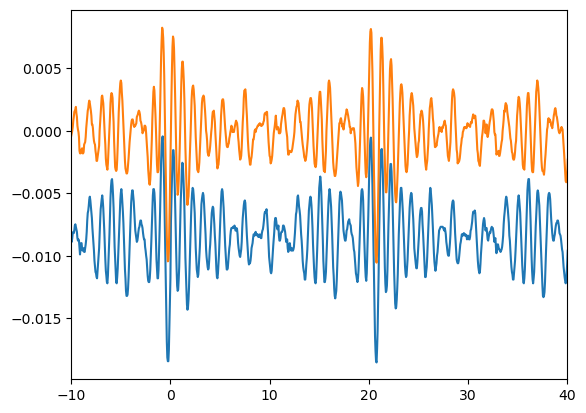

In [858]:
plt.plot(t1,d1)
#plt.plot(t2,d2)
plt.plot(t2,db-d2)
plt.xlim([-10,40])

In [859]:
print(nper_probe,dt)
print(nt,nper_pulse)
print(1/dt)

19 0.05208312499999579
3839 81
19.200076800308754


-0.04158250000000052
1.9999999999242846e-05
53
-37.239594375


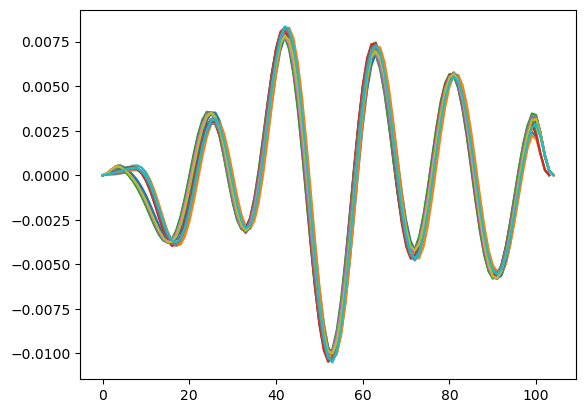

In [860]:
per_pulse=21 #in us repetition rate of the high-f probe
nper_pulse=int(per_pulse/dt)+1
print(per_pulse-t[nper_pulse]+t[0])  #should be less than dt
per_probe=5 # in us period of the probe
nper_probe=int(per_probe/dt)
print(per_probe-t[nper_probe]+t[0])

sigBOTH=db
sigPUMP=d2
sigprobe=d1
sigprobe_pert=db-d2

winlen=int(nper_probe/2+5)
print(winlen)
print(t[winlen]+t[0])

it_first_pulse=np.argmax(np.abs(d1[:ntend])) #Assumes that the first peak is within the first 100 points

itstart=int(it_first_pulse)
tshiftlist=[]
twinlist=[]
npulses=0
while itstart < nt-winlen:
    #plt.figure()
    
    sig1=sigprobe[itstart-winlen:itstart+winlen]
    sig3=sigprobe_pert[itstart-winlen:itstart+winlen]
    sig2=sigPUMP[itstart-winlen:itstart+winlen]
    tplot=t[itstart-winlen:itstart+winlen]/1e6
    twinlist.append(t[itstart])
    tshiftlist.append(compdelay(tplot,sig1,sig2,sig3,winlen=10,probe_filter_cut=1.5e6))
    itstart=int(it_first_pulse)+int(npulses*per_pulse/dt)+1
    npulses+=1
   

[np.float64(-9.594085493580923e-09), np.float64(-9.482015421561889e-09), np.float64(-1.1082839904309837e-08), np.float64(-9.276445237537383e-09), np.float64(-9.339083723377752e-09), np.float64(-1.1623379502358071e-08), np.float64(-1.103474003138841e-08), np.float64(-1.0047374879735863e-08), np.float64(-1.0066380929739326e-08), np.float64(-1.0553023614513929e-08)]


Text(0.5, 0, 'window centre (us)')

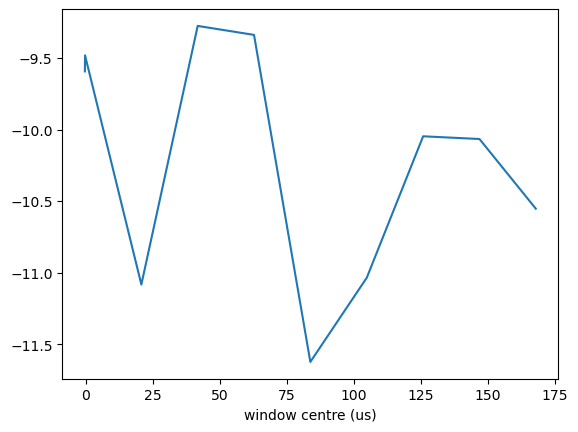

In [861]:
print(tshiftlist)
tshift=np.array(tshiftlist)
twin=np.array(twinlist)
plt.plot(twin,tshift*1e9)
plt.xlabel('time shift (ns)')
plt.xlabel('window centre (us)')

2.8406718864785927e-09


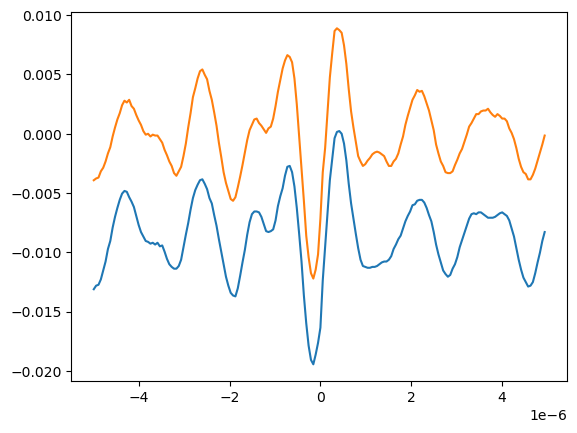

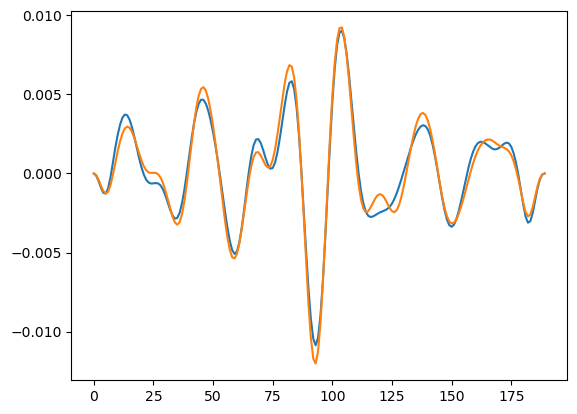

In [807]:
Tp=21

winlen=10

iwin0=np.argmin(np.abs(t1))

iwinlen=np.argmin(np.abs(winlen-t1))-iwin0

win1=np.arange(iwin0-int(iwinlen/2),iwin0+int(iwinlen/2),dtype='int')

nt=np.size(win1)

activechannelnames=[1]

probedat=[timedata(ch) for ch in activechannelnames]
PUMPdat=[timedata(ch) for ch in activechannelnames]
bothdat=[timedata(ch) for ch in activechannelnames]

probedat[0].time=t1[win1]/1e6
probedat[0].data=d1[win1]

PUMPdat[0].time=t2[win1]/1e6
PUMPdat[0].data=d2[win1]

bothdat[0].time=tb[win1]/1e6
bothdat[0].data=db[win1]

plt.plot(probedat[0].time,probedat[0].data)
plt.plot(probedat[0].time,bothdat[0].data-PUMPdat[0].data)
plt.figure()
tshift=Compute_single_delay(bothdat,probedat,PUMPdat,0,winlen)
print(tshift)
#plt.plot(t1,d1)
#plt.plot(t1[win1],d1[win1])

#plt.plot(t1+29.25,d1)
#plt.plot(t1+2*29.25,d1)
#plt.xlim([-10,10])

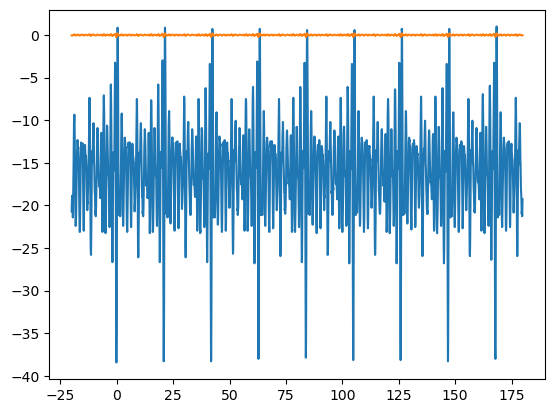

In [808]:
plt.plot(tb,db/np.max(db))
#plt.plot(t1,d1/np.max(d1))
#plt.plot(tb,(db-d2)/np.max(db-d2))
plt.plot(tb,20*(db-d2))
#plt.xlim([0,5])

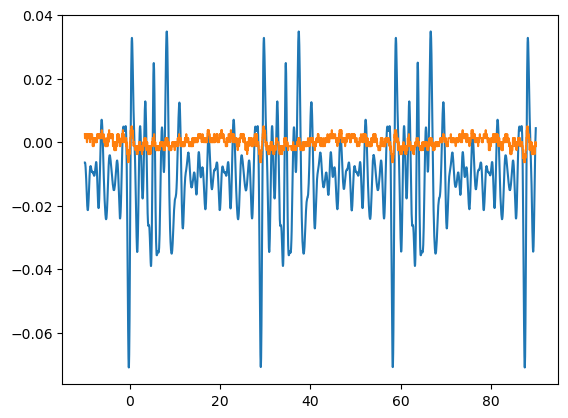

In [80]:
plt.plot(t1,d1)
plt.plot(tb,db-d2)

In [82]:
datcor1=np.correlate(d1-np.mean(d1),d1-np.mean(d1),mode='full')
datcor_diff=np.correlate(ddiff-np.mean(ddiff),ddiff-np.mean(ddiff),mode='full')

In [89]:
nt=np.size(t1)
dt=t1[1]-t1[0]
tcor=np.arange(-nt+1,nt)*dt

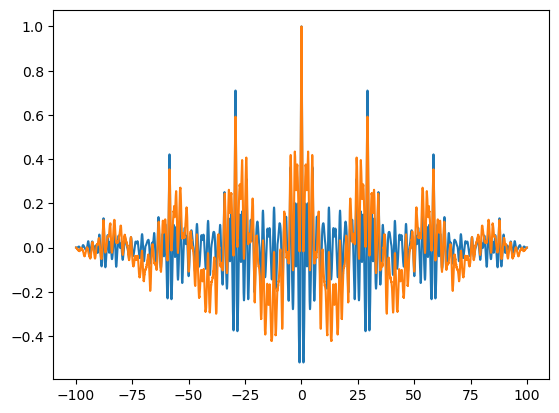

In [90]:
plt.plot(tcor,datcor1/np.max(datcor1))
plt.plot(tcor,datcor_diff/np.max(datcor_diff))

In [91]:
pklocs1=scipy.signal.find_peaks(datcor1,distance=700)
pklocsd=scipy.signal.find_peaks(datcor_diff,distance=700)

In [104]:
ii=0
t_shift1=np.zeros(np.size(pklocs1[0]))
for pk in pklocs1[0]:
    tvals=tcor[pk-1:pk+2]
    xvals=datcor1[pk-1:pk+2]

    Fit_to_peak=np.polyfit(tvals,xvals,2)

    MaxPeak_from_interpolation=-Fit_to_peak[1]/2/Fit_to_peak[0]
    t_shift1[ii]=MaxPeak_from_interpolation
    ii=ii+1
t1_diff=t_shift1[:-1]-t_shift1[1:]


In [105]:
ii=0
t_shiftd=np.zeros(np.size(pklocsd[0]))
for pk in pklocsd[0]:
    tvals=tcor[pk-1:pk+2]
    xvals=datcor1[pk-1:pk+2]

    Fit_to_peak=np.polyfit(tvals,xvals,2)

    MaxPeak_from_interpolation=-Fit_to_peak[1]/2/Fit_to_peak[0]
    t_shiftd[ii]=MaxPeak_from_interpolation
    ii=ii+1
td_diff=t_shiftd[:-1]-t_shiftd[1:]

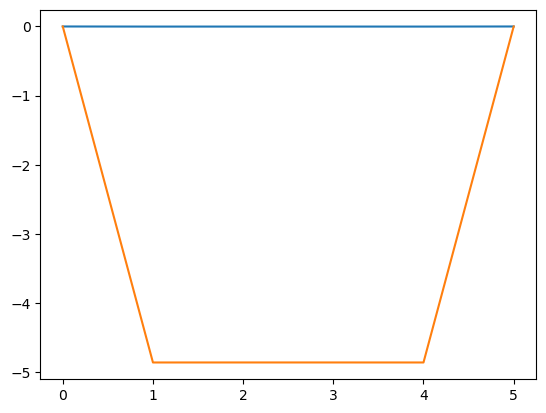

In [106]:
plt.plot(t1_diff-t1_diff[0])
plt.plot(td_diff-td_diff[0])

In [107]:
print(t1_diff-t1_diff[0])
print(td_diff-td_diff[0])

[ 0.00000000e+00 -1.46646369e-03 -1.23583011e-03 -1.23583011e-03
 -1.46646368e-03 -2.43716158e-11]
[ 0.00000000e+00 -4.85726442e+00 -4.85703379e+00 -4.85703379e+00
 -4.85726442e+00 -3.24007488e-10]


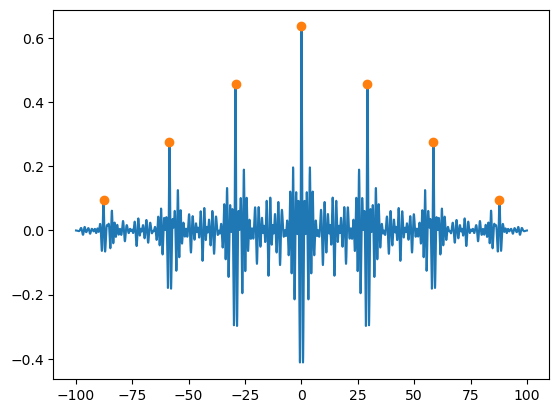

In [55]:
plt.plot(tcor,datcor)
plt.plot(tcor[pklocs[0]],datcor[pklocs[0]],'o')

In [58]:
tcor[pklocs[0][:-1]]-tcor[pklocs[0][1:]]

array([-29.24432375, -29.270365  , -29.24432375, -29.24432375,
       -29.270365  , -29.24432375])

In [93]:
.6*25

15.0

I need to correlate each peak with its corresponding peak not with all of them. 